<a href="https://colab.research.google.com/github/bhumikabatra13609/AIML-Project/blob/main/Restaurant_Rating_Prediction_(Regression).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [ ]:
df = pd.read_csv("/content/Dataset .csv")
print(df.head())

   Restaurant ID         Restaurant Name  Country Code              City  \
0        6317637        Le Petit Souffle           162       Makati City   
1        6304287        Izakaya Kikufuji           162       Makati City   
2        6300002  Heat - Edsa Shangri-La           162  Mandaluyong City   
3        6318506                    Ooma           162  Mandaluyong City   
4        6314302             Sambo Kojin           162  Mandaluyong City   

                                             Address  \
0  Third Floor, Century City Mall, Kalayaan Avenu...   
1  Little Tokyo, 2277 Chino Roces Avenue, Legaspi...   
2  Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...   
3  Third Floor, Mega Fashion Hall, SM Megamall, O...   
4  Third Floor, Mega Atrium, SM Megamall, Ortigas...   

                                     Locality  \
0   Century City Mall, Poblacion, Makati City   
1  Little Tokyo, Legaspi Village, Makati City   
2  Edsa Shangri-La, Ortigas, Mandaluyong City   
3      SM 

In [ ]:
df.fillna(df.mean(numeric_only=True), inplace=True)
df.fillna("Unknown", inplace=True)

In [ ]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [ ]:
print(df.columns)


Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')


In [ ]:
target_column = "Aggregate rating"


In [ ]:
X = df_encoded.drop(columns=[target_column])
y = df_encoded[target_column]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Mean Squared Error (MSE):", mse)
print("R² Score:", r2)

Mean Squared Error (MSE): 0.09186272044663672
R² Score: 0.9596404562181593



Top 10 Important Features:
Address_36, Food Court, 2nd Floor, Pacific Mall, Tagore Garden, New Delhi    1.271921
Rating text_Excellent                                                        1.135825
Address_K 11, Som Vihar Apartments, R K Puram, New Delhi                     1.130113
Address_E-778, Market 2, Chittaranjan Park, New Delhi                        1.021420
Restaurant Name_Cocoberry                                                    0.978862
Address_Ground Floor, Shipra Mall, Indirapuram, Ghaziabad                    0.975611
Address_A-353, 7, Derawala Nagar, Gujranwala Town, New Delhi                 0.873184
Address_M-2/A, M Block Market, Greater Kailash (GK) 1, New Delhi             0.864726
Address_29, Defence Colony Market, Defence Colony, New Delhi                 0.859243
Address_Food Court, 3rd Floor, MGF Metropolitan Mall, MG Road, Gurgaon       0.822588
dtype: float64


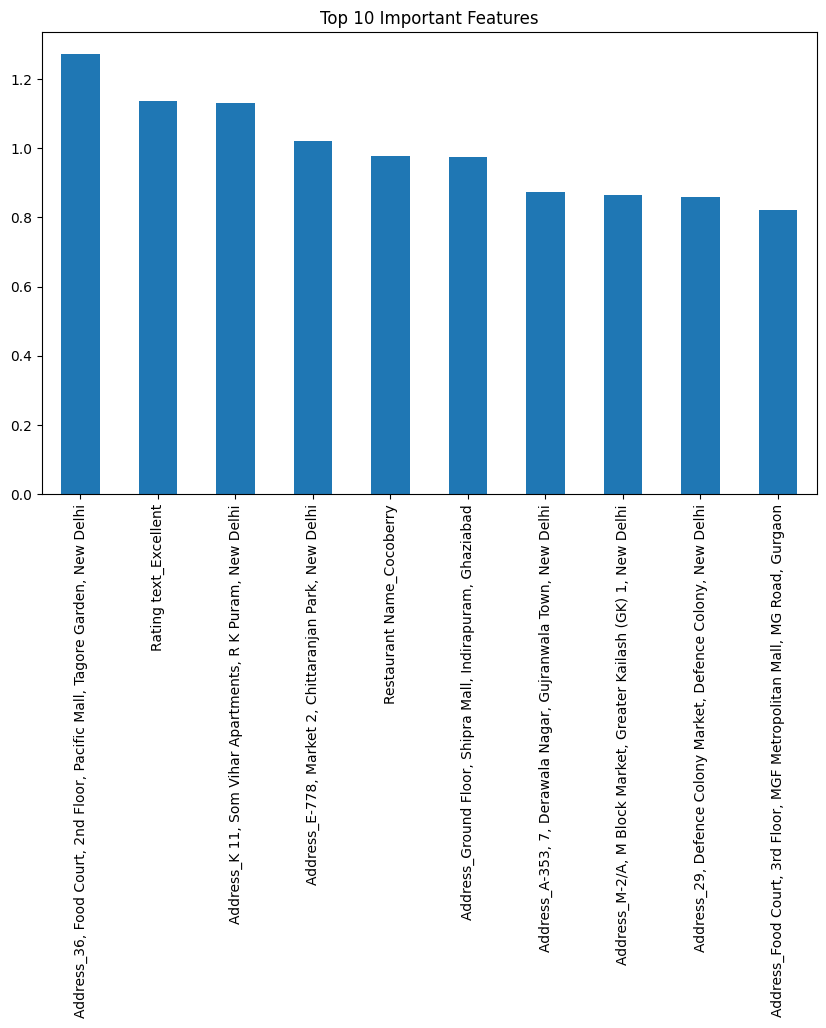

In [ ]:
importance = pd.Series(model.coef_, index=X.columns)
importance = importance.sort_values(ascending=False)

print("\nTop 10 Important Features:")
print(importance.head(10))

# Plot
plt.figure(figsize=(10,6))
importance.head(10).plot(kind='bar')
plt.title("Top 10 Important Features")
plt.show()


🌲 Random Forest Performance
MSE: 0.02741052904238611
R² Score: 0.9879572862463589


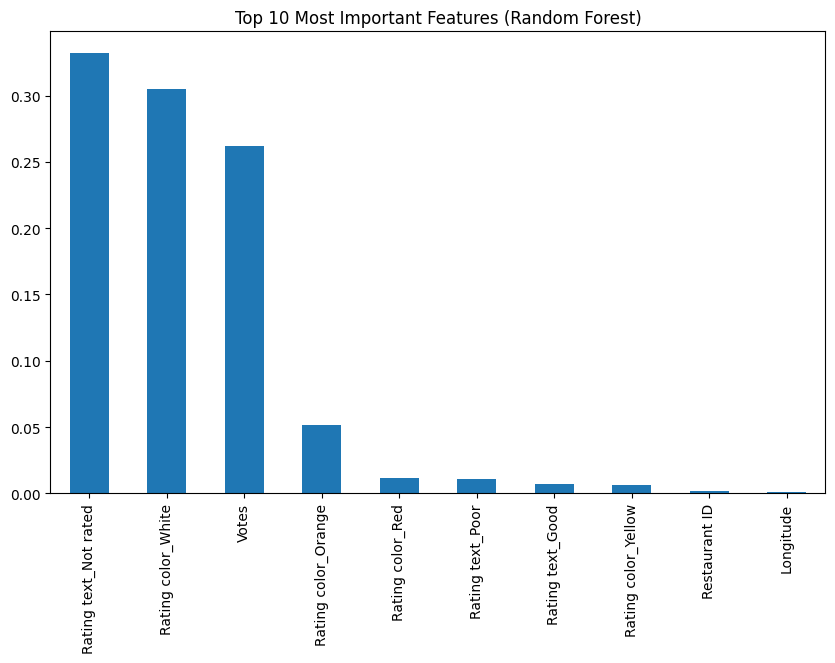

In [ ]:
rf = RandomForestRegressor()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("\n🌲 Random Forest Performance")
print("MSE:", mse_rf)
print("R² Score:", r2_rf)
rf_importance = pd.Series(rf.feature_importances_, index=X.columns)
rf_importance = rf_importance.sort_values(ascending=False)

plt.figure(figsize=(10,6))
rf_importance.head(10).plot(kind='bar')
plt.title("Top 10 Most Important Features (Random Forest)")
plt.show()